# Experimenting in TensorFlow and Keras

## Environment setup

In [1]:
from functools import partial
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, Dense, GlobalAveragePooling2D,
    Input, MaxPool2D, Dropout,
    Rescaling, RandomRotation, RandomFlip, RandomSharpness,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import set_random_seed, image_dataset_from_directory

# Suppress all warnings (mostly from Keras recommendations)
def warn(*args, **kwargs):
    pass

warnings.warn = warn

2026-05-02 13:00:40.621721: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-02 13:00:41.663800: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-02 13:00:44.490688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Define config parameters (copied from config/config.py)

# Global config
RANDOM_SEED = 147

# Project structure
PACKAGE_ROOT = Path("../src/celebrity_faces")
ARTIFACTS_DIR = PACKAGE_ROOT / "artifacts"
DATA_DIR = PACKAGE_ROOT / "data"
METRICS_DIR = PACKAGE_ROOT / "metrics"
MODEL_DIR = PACKAGE_ROOT / "model"

In [3]:
class Pipeline:
    def __init__(self):
        self._layers = {
            "rescaling": Rescaling(1.0 / 255),
            "augmentation": Sequential([
                RandomRotation(0.1),
                RandomFlip("horizontal")
            ]),
        }

        self.train_ds = self._train_pipeline()
        self.val_ds = self._val_pipeline()
        self.test_ds = self._test_pipeline()

    def _train_pipeline(self):
        # Load train set with shuffling
        ds = image_dataset_from_directory(
            DATA_DIR / "train",
            labels="inferred",
            label_mode="int",
            batch_size=BATCH_SIZE,
            image_size=IMAGE_SIZE,
            shuffle=True,
            seed = RANDOM_SEED,
            crop_to_aspect_ratio=True,
            data_format="channels_last",
            verbose=False,
        )
        self.train_labels = ds.class_names

        # Rescale to achieve more stable convergence
        ds = ds.map(
            lambda x, y: (self._layers["rescaling"](x), y),
            num_parallel_calls=1
        )

        return ds

    def _val_pipeline(self):
        # Load validation set without shuffling
        ds = image_dataset_from_directory(
            DATA_DIR / "validation",
            labels="inferred",
            label_mode="int",
            batch_size=BATCH_SIZE,
            image_size=IMAGE_SIZE,
            shuffle=False,
            crop_to_aspect_ratio=True,
            data_format="channels_last",
            verbose=False,
        )
        self.val_labels = ds.class_names

        # Rescale to achieve more stable convergence
        ds = ds.map(
            lambda x, y: (self._layers["rescaling"](x), y),
            num_parallel_calls=1
        )

        return ds

    def _test_pipeline(self):
        # Load test set without shuffling
        ds = image_dataset_from_directory(
            DATA_DIR / "test",
            labels="inferred",
            label_mode="int",
            batch_size=BATCH_SIZE,
            image_size=IMAGE_SIZE,
            shuffle=False,
            crop_to_aspect_ratio=True,
            data_format="channels_last",
            verbose=False,
        )
        self.test_labels = ds.class_names

        # Rescale to achieve more stable convergence
        ds = ds.map(
            lambda x, y: (self._layers["rescaling"](x), y),
            num_parallel_calls=1
        )

        return ds

In [4]:
def train(model, pipeline, optimizer, epochs=50):
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"],
    )

    # Setup callbacks
    #early_stopping_cb = EarlyStopping(
    #    monitor="val_loss", min_delta=0.001, patience=8, restore_best_weights=True
    #)

    history = model.fit(
        pipeline.train_ds,
        epochs=epochs,
        validation_data=pipeline.val_ds,
    #    callbacks=[early_stopping_cb],
    )

    return history

In [5]:
def plot_learning_curves(hist):
    epochs = len(hist.history["loss"])
    fig, ax = plt.subplots(1, 2, figsize=(10, 6))
    ax[0].plot(range(1, epochs+1), hist.history['accuracy'], 'b-', label='Train accuracy')
    ax[0].plot(range(1, epochs+1), hist.history['val_accuracy'], 'r-', label='Validation accuracy')
    ax[0].set(xlabel='Epoch', ylabel='Accuracy')
    ax[0].legend()
    
    ax[1].plot(range(1, epochs+1), hist.history['loss'], 'b-', label='Train loss')
    ax[1].plot(range(1, epochs+1), hist.history['val_loss'], 'r-', label='Validation loss')
    ax[1].set(xlabel='Epoch', ylabel='Loss')
    ax[1].legend()
    
    plt.show()

In [6]:
set_random_seed(RANDOM_SEED)

# TF determinism (TF 2.13+)
tf.config.experimental.enable_op_determinism()

# Optional: make runs identical at the cost of speed
os.environ["TF_DETERMINISTIC_OPS"] = "1"

## Experiment 1

**Minimal Baseline**

We'll do this experiment with the following settings :
- Objective : First intuition about model capacity on a noisy dataset (not preprocessed for face detection)
- Use two single conv blocks (32+64) with image augmentation (IA), using Adam optimizer, no GPU optimization
- Use a 64-node dense layer head with no Dropout
- Try bigger image size first (200x200) if no OOM error, otherwise try medium image size (160x160)
- Try medium (16) or bigger (32) batch size
- Train for 50 epochs without early stopping (GPU)

In [7]:
def baseline_model(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential([
        Input(shape=in_shape),
        augmentation,
        # Conv2D block #1
        def_conv2d(filters=32),
        MaxPool2D(),
        # Conv2D block #2
        def_conv2d(filters=64),
        GlobalAveragePooling2D(),
        Dense(units=64, activation="relu", kernel_initializer="he_normal"),
        # Dropout(0.25),
        Dense(units=10, activation="softmax"),
    ])

    return model

In [8]:
IMAGE_SIZE = (200, 200)
BATCH_SIZE = 16

In [9]:
pipeline = Pipeline()
input_shape = IMAGE_SIZE + (3,)

I0000 00:00:1777714607.351791   98189 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1353 MB memory:  -> device: 0, name: NVIDIA GeForce MX570 A, pci bus id: 0000:01:00.0, compute capability: 8.6


### Train with Adam optimizer

In [10]:
model = baseline_model(input_shape)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,202 (94.54 KB)

 Trainable params: 24,202 (94.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
optimizer = Adam(learning_rate=3e-4)
epochs = 50

In [12]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/50


2026-05-02 13:08:01.354359: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.1013 - loss: 2.3606 - val_accuracy: 0.0900 - val_loss: 2.2989
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1088 - loss: 2.2991 - val_accuracy: 0.1300 - val_loss: 2.2904
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1213 - loss: 2.2912 - val_accuracy: 0.0800 - val_loss: 2.2814
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1350 - loss: 2.2809 - val_accuracy: 0.1400 - val_loss: 2.2702
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1488 - loss: 2.2706 - val_accuracy: 0.1900 - val_loss: 2.2507
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1450 - loss: 2.2520 - val_accuracy: 0.1500 - val_loss: 2.2461
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1513 - loss: 2.2373 - val_accuracy: 0.1700 - val_loss: 2.2317
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1637 - loss: 2.2181 - val_accuracy: 0.1600 - val_loss: 2.

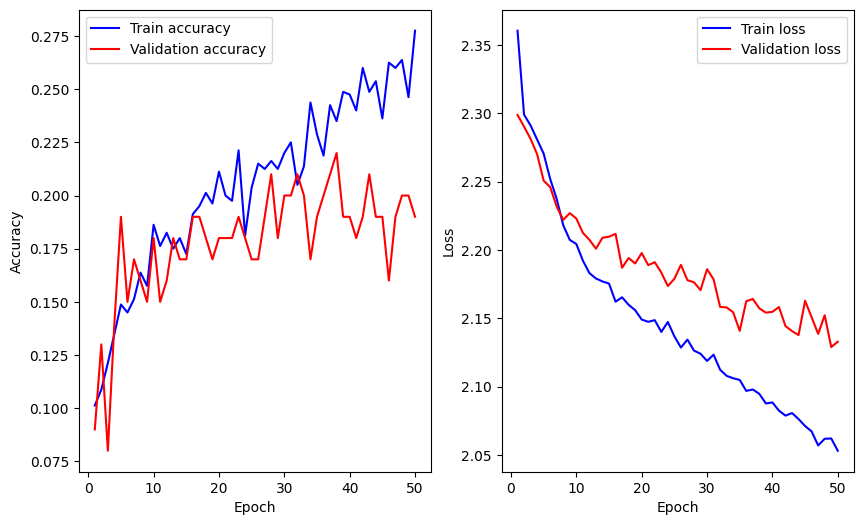

In [13]:
plot_learning_curves(history)

## Experiment 2

**Better Baseline**

We'll do this experiment with the following settings :
- Objective : Inspecting the effects of model capacity vs. optimization
- Use three single conv blocks (32+64+128) with image augmentation (IA), using different optimizers, no GPU optimization
- Use a 64-node dense layer head with no Dropout
- Try bigger image size first (200x200) if no OOM error, otherwise try medium image size (160x160)
- Try medium (16) or bigger (32) batch size
- Train for 50 epochs without early stopping (GPU)

In [14]:
def better_baseline(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential([
        Input(shape=in_shape),
        augmentation,
        # Conv2D block #1
        def_conv2d(filters=32),
        MaxPool2D(),
        # Conv2D block #2
        def_conv2d(filters=64),
        MaxPool2D(),
        # Conv2D block #3
        def_conv2d(filters=128),
        GlobalAveragePooling2D(),
        Dense(units=64, activation="relu", kernel_initializer="he_normal"),
        Dense(units=10, activation="softmax"),
    ])

    return model

### Training with Adam optimizer

In [15]:
model = better_baseline(input_shape)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,154 (399.04 KB)

 Trainable params: 102,154 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
optimizer = Adam(learning_rate=3e-4)
epochs = 30

In [17]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.1063 - loss: 2.3175 - val_accuracy: 0.1100 - val_loss: 2.3071
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.1138 - loss: 2.2992 - val_accuracy: 0.1500 - val_loss: 2.2935
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1163 - loss: 2.2781 - val_accuracy: 0.0900 - val_loss: 2.2777
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1500 - loss: 2.2558 - val_accuracy: 0.1700 - val_loss: 2.3354
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1388 - loss: 2.2395 - val_accuracy: 0.1800 - val_loss: 2.2987
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1562 - loss: 2.2277 - val_accuracy: 0.1700 - val_loss: 2.3012
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1550 - loss: 2.2231 - val_accuracy: 0.1700 - val_loss: 2.2869
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1737 - loss: 2.2054 - val_accuracy: 0.2100 - v

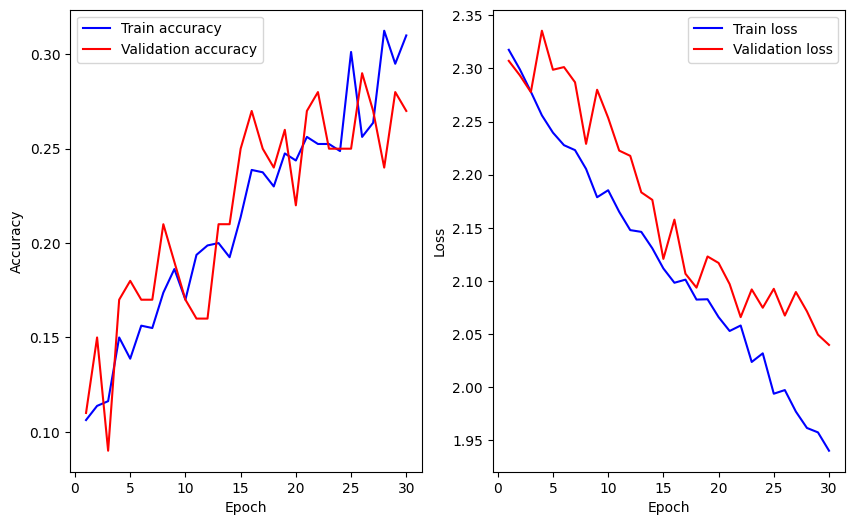

In [18]:
plot_learning_curves(history)

### Training with RMSprop optimizer

In [19]:
model = better_baseline(input_shape)

In [20]:
optimizer = RMSprop(learning_rate=3e-4)
epochs = 30

In [21]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.1013 - loss: 2.3226 - val_accuracy: 0.1000 - val_loss: 2.2899
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1175 - loss: 2.2948 - val_accuracy: 0.1300 - val_loss: 2.2858
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1250 - loss: 2.2723 - val_accuracy: 0.1100 - val_loss: 2.2881
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1350 - loss: 2.2618 - val_accuracy: 0.1400 - val_loss: 2.3020
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.1525 - loss: 2.2516 - val_accuracy: 0.0900 - val_loss: 2.2765
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.1488 - loss: 2.2379 - val_accuracy: 0.1400 - val_loss: 2.2847
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1663 - loss: 2.2327 - val_accuracy: 0.1300 - val_loss: 2.2869
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1562 - loss: 2.2195 - val_accuracy: 0.1600 - v

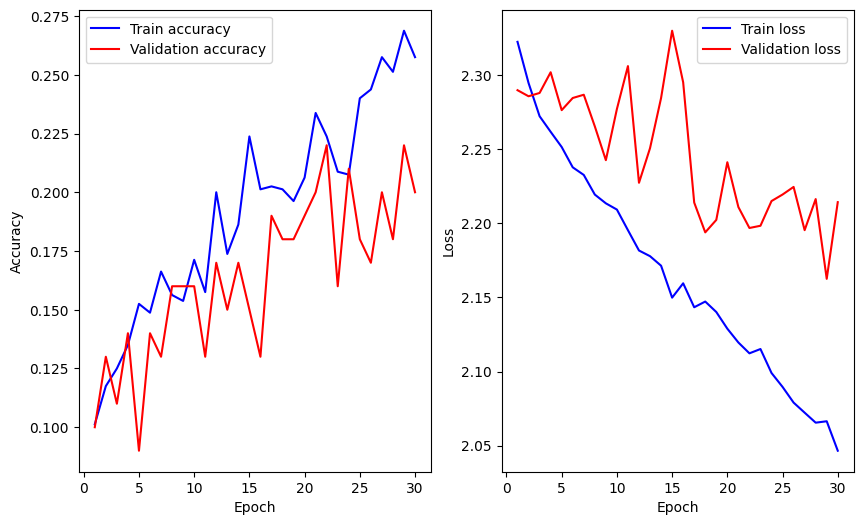

In [22]:
plot_learning_curves(history)

### Training with SGD optimizer

In [23]:
model = better_baseline(input_shape)

In [24]:
optimizer = SGD(learning_rate=0.01, momentum=0.9)
epochs = 30

In [25]:
history = train(model, pipeline, optimizer, epochs)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.0875 - loss: 2.3398 - val_accuracy: 0.1100 - val_loss: 2.2962
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1163 - loss: 2.2962 - val_accuracy: 0.1600 - val_loss: 2.2871
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1150 - loss: 2.2956 - val_accuracy: 0.1500 - val_loss: 2.3151
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1150 - loss: 2.2996 - val_accuracy: 0.0900 - val_loss: 2.2949
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1475 - loss: 2.2739 - val_accuracy: 0.1500 - val_loss: 2.2848
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.1400 - loss: 2.2651 - val_accuracy: 0.1100 - val_loss: 2.2970
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.1350 - loss: 2.2624 - val_accuracy: 0.1300 - val_loss: 2.2747
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1325 - loss: 2.2487 - val_accuracy: 0.1300 - v

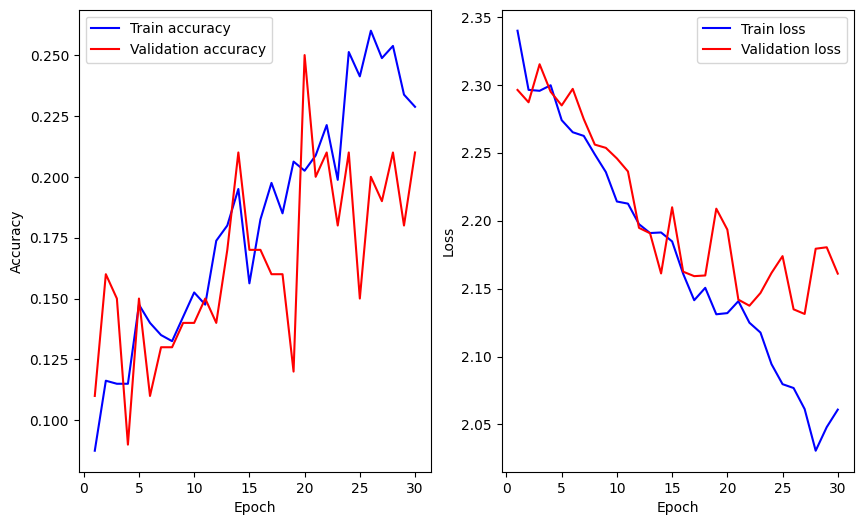

In [26]:
plot_learning_curves(history)

## Experiment 3

**Regularization**

We'll do this experiment with the following settings :
- Objective : Inspecting the effects of regularization and augmentation
- Use three single conv blocks (32+64+128), same as previous experiment
- Only add dropout to head (0.3)
- Only add random sharpness to IA
- Add both dropout and random sharpness
- Train for 30 epochs with Adam (GPU)

In [27]:
def fit(model, pipeline, epochs=30):
    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"],
    )

    history = model.fit(
        pipeline.train_ds,
        epochs=epochs,
        validation_data=pipeline.val_ds,
    )

    return history

### New baseline

In [28]:
def new_baseline(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential([
        Input(shape=in_shape),
        augmentation,
        # Conv2D block #1
        def_conv2d(filters=32),
        MaxPool2D(),
        # Conv2D block #2
        def_conv2d(filters=64),
        MaxPool2D(),
        # Conv2D block #3
        def_conv2d(filters=128),
        GlobalAveragePooling2D(),
        Dense(units=64, activation="relu", kernel_initializer="he_normal"),
        Dense(units=10, activation="softmax"),
    ])

    return model

In [29]:
model = new_baseline(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.1063 - loss: 2.3378 - val_accuracy: 0.1200 - val_loss: 2.2964
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.1175 - loss: 2.3056 - val_accuracy: 0.1200 - val_loss: 2.2941
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.1213 - loss: 2.2851 - val_accuracy: 0.1200 - val_loss: 2.2857
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1488 - loss: 2.2596 - val_accuracy: 0.1200 - val_loss: 2.2742
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1575 - loss: 2.2412 - val_accuracy: 0.1300 - val_loss: 2.2555
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.1737 - loss: 2.2151 - val_accuracy: 0.1200 - val_loss: 2.2360
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1725 - loss: 2.1996 - val_accuracy: 0.1300 - val_loss: 2.2187
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.1825 - loss: 2.1898 - val_accuracy: 0.1500 - v

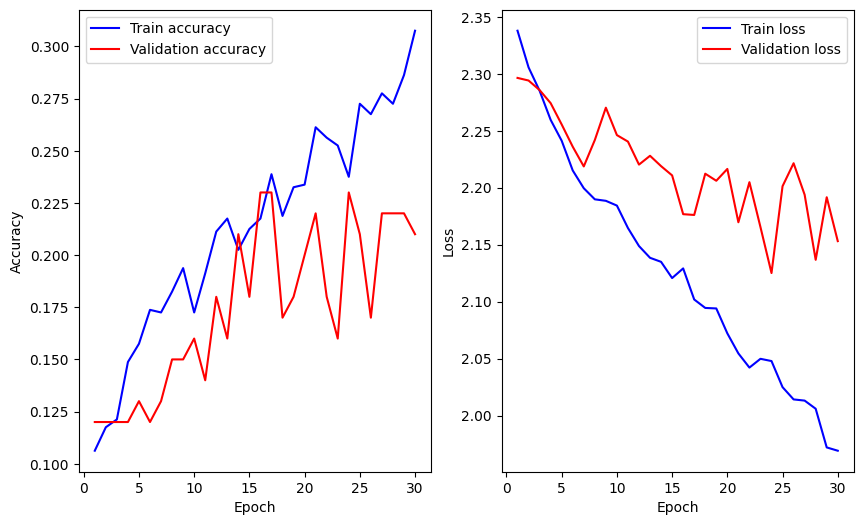

In [30]:
plot_learning_curves(history)

### Baseline with dropout

In [31]:
def new_baseline_dropout(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential([
        Input(shape=in_shape),
        augmentation,
        # Conv2D block #1
        def_conv2d(filters=32),
        MaxPool2D(),
        # Conv2D block #2
        def_conv2d(filters=64),
        MaxPool2D(),
        # Conv2D block #3
        def_conv2d(filters=128),
        GlobalAveragePooling2D(),
        Dense(units=64, activation="relu", kernel_initializer="he_normal"),
        Dropout(0.3),
        Dense(units=10, activation="softmax"),
    ])

    return model

In [32]:
model = new_baseline_dropout(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.1000 - loss: 2.3523 - val_accuracy: 0.1000 - val_loss: 2.3047
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.0850 - loss: 2.3224 - val_accuracy: 0.1100 - val_loss: 2.2862
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.0962 - loss: 2.3113 - val_accuracy: 0.1500 - val_loss: 2.2809
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1400 - loss: 2.2925 - val_accuracy: 0.1300 - val_loss: 2.2890
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1338 - loss: 2.2887 - val_accuracy: 0.1900 - val_loss: 2.2485
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1275 - loss: 2.2798 - val_accuracy: 0.1200 - val_loss: 2.2562
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.1488 - loss: 2.2628 - val_accuracy: 0.2300 - val_loss: 2.2171
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1437 - loss: 2.2453 - val_accuracy: 0.1500 - v

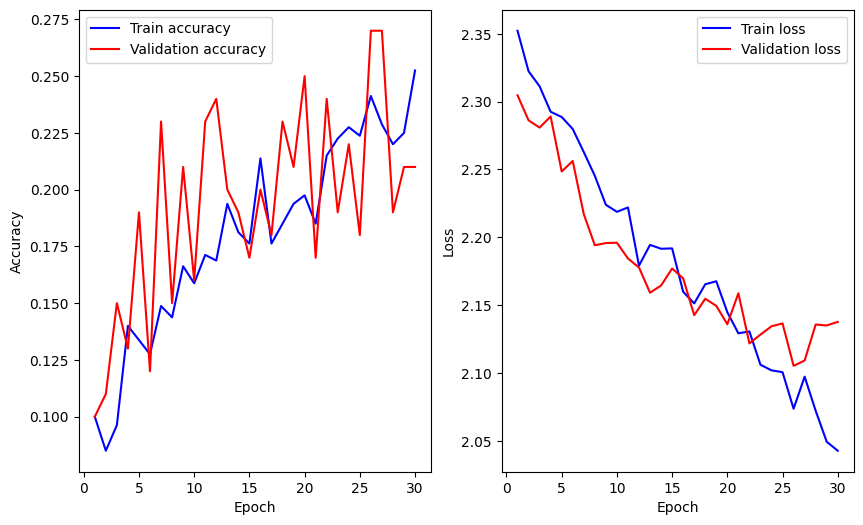

In [33]:
plot_learning_curves(history)

### Baseline with improved augmentation

In [34]:
def new_baseline_augment(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomSharpness(factor=0.4, value_range=[0, 1]), # Slight blur (close to 0.5: No Blur)
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential([
        Input(shape=in_shape),
        augmentation,
        # Conv2D block #1
        def_conv2d(filters=32),
        MaxPool2D(),
        # Conv2D block #2
        def_conv2d(filters=64),
        MaxPool2D(),
        # Conv2D block #3
        def_conv2d(filters=128),
        GlobalAveragePooling2D(),
        Dense(units=64, activation="relu", kernel_initializer="he_normal"),
        Dense(units=10, activation="softmax"),
    ])

    return model

In [35]:
model = new_baseline_augment(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.1125 - loss: 2.3112 - val_accuracy: 0.1100 - val_loss: 2.2967
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.1325 - loss: 2.2876 - val_accuracy: 0.1100 - val_loss: 2.2804
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1287 - loss: 2.2677 - val_accuracy: 0.1300 - val_loss: 2.2607
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1363 - loss: 2.2506 - val_accuracy: 0.1500 - val_loss: 2.2616
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.1488 - loss: 2.2317 - val_accuracy: 0.1400 - val_loss: 2.2417
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1575 - loss: 2.2143 - val_accuracy: 0.1700 - val_loss: 2.2400
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.1950 - loss: 2.1922 - val_accuracy: 0.1600 - val_loss: 2.2688
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1887 - loss: 2.1906 - val_accuracy: 0.1700 - v

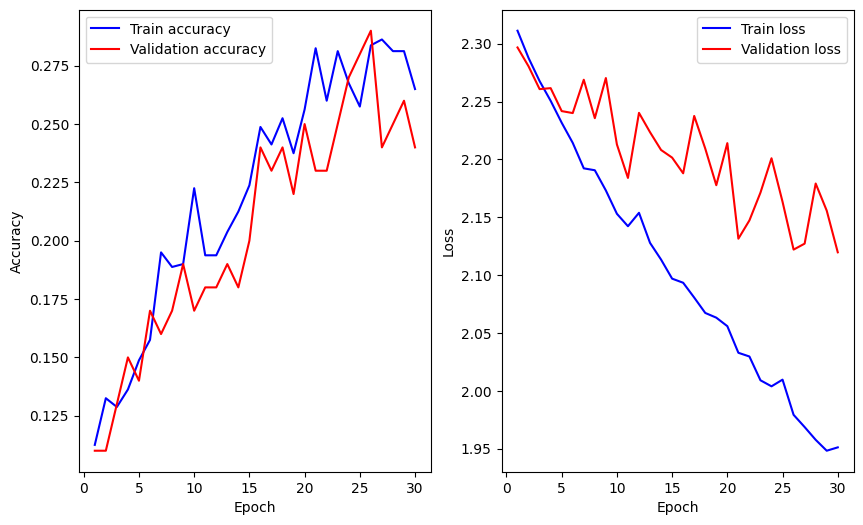

In [36]:
plot_learning_curves(history)

### Baseline with dropout and augmentation

In [37]:
def new_baseline_dropout_augment(in_shape):
    def_conv2d = partial(
        Conv2D,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        activation="relu",
    )

    augmentation = Sequential([
        RandomSharpness(factor=0.4, value_range=[0, 1]), # Slight blur (close to 0.5: No Blur)
        RandomRotation(0.1),
        RandomFlip("horizontal"),
    ])
    model = Sequential([
        Input(shape=in_shape),
        augmentation,
        # Conv2D block #1
        def_conv2d(filters=32),
        MaxPool2D(),
        # Conv2D block #2
        def_conv2d(filters=64),
        MaxPool2D(),
        # Conv2D block #3
        def_conv2d(filters=128),
        GlobalAveragePooling2D(),
        Dense(units=64, activation="relu", kernel_initializer="he_normal"),
        Dropout(0.3),
        Dense(units=10, activation="softmax"),
    ])

    return model

In [38]:
model = new_baseline_dropout_augment(input_shape)
history = fit(model, pipeline)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.0938 - loss: 2.3514 - val_accuracy: 0.1000 - val_loss: 2.2987
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.0962 - loss: 2.3075 - val_accuracy: 0.0900 - val_loss: 2.3005
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.1112 - loss: 2.3006 - val_accuracy: 0.1000 - val_loss: 2.2948
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1037 - loss: 2.3019 - val_accuracy: 0.1400 - val_loss: 2.2858
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.1088 - loss: 2.2890 - val_accuracy: 0.1300 - val_loss: 2.2897
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.1200 - loss: 2.2862 - val_accuracy: 0.1000 - val_loss: 2.2788
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1238 - loss: 2.2799 - val_accuracy: 0.1100 - val_loss: 2.2659
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1225 - loss: 2.2760 - val_accuracy: 0.1600 - v

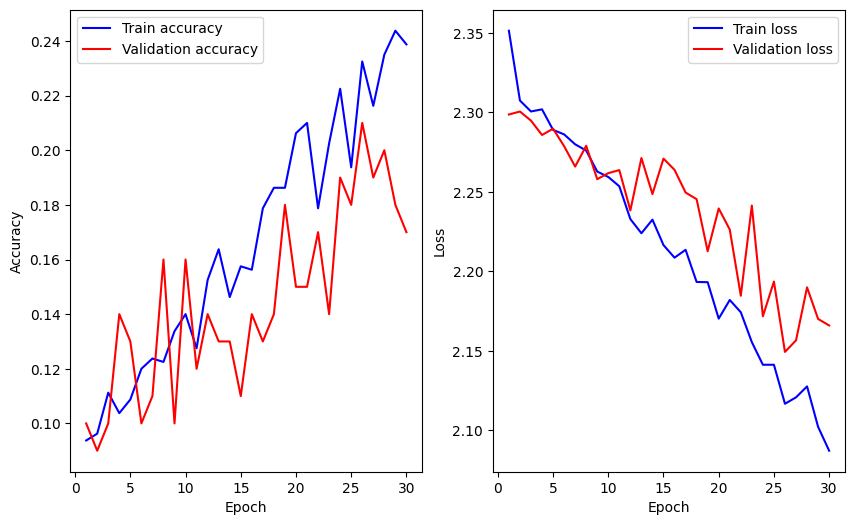

In [39]:
plot_learning_curves(history)